# FSDP Step by Step

## Understanding Fully-Sharded Data Parallelism from First Principles

**Scenario**: A genomics lab trains a drug response classifier on gene expression data. The model is too large to fit on a single GPU. Standard **Data Parallelism (DP)** replicates the full model on every device, wasting memory. **FSDP** solves this by **sharding parameters** across devices.

This notebook builds up FSDP piece by piece:

1. **The memory problem** — why DP doesn't scale
2. **Sharding a single array** — the basic building block
3. **`all_gather`** — reassembling a full array from shards
4. **`psum_scatter`** — distributing gradients back to shards
5. **Custom gradient** — combining gather (forward) with scatter (backward)
6. **Sharding model parameters** — applying sharding to real weights
7. **Module wrapping** — making gather/shard transparent to the model
8. **Mixed sharding** — handling small parameters that stay replicated
9. **Full FSDP training** — putting it all together

Based on the [UvA DLC FSDP tutorial](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/scaling/JAX/data_parallel_fsdp.html).

---

## 1 — Setup

In [1]:
import os

N_DEVICES = 8
os.environ["XLA_FLAGS"] = f"--xla_force_host_platform_device_count={N_DEVICES}"
os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [2]:
import functools
import warnings
from dataclasses import dataclass
from pprint import pprint
from typing import Any, Callable, Sequence, Tuple

import flax.linen as nn
import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import optax
from flax.training import train_state
from jax import lax, random
from jax.experimental.shard_map import shard_map
from jax.sharding import Mesh, PartitionSpec as P
from ml_collections import ConfigDict

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams["font.family"] = "DejaVu Sans"

# Type aliases
PyTree = Any
Metrics = dict
Parameter = Any

print(f"JAX version: {jax.__version__}")
print(f"Devices: {jax.devices()}")
print(f"Number of devices: {len(jax.devices())}")

JAX version: 0.9.0.1
Devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]
Number of devices: 8


/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_45957/3914724433.py:16: DeprecationWarning: jax.experimental.shard_map is deprecated in v0.8.0. Used jax.shard_map instead.
  from jax.experimental.shard_map import shard_map


---

## 2 — The Memory Problem with Data Parallelism

In standard **Data Parallelism**, every device holds a **full copy** of the model:

```
Device 0:  [Full W₁]  [Full W₂]  [Full W₃]    ← all 100% of params
Device 1:  [Full W₁]  [Full W₂]  [Full W₃]    ← all 100% of params
Device 2:  [Full W₁]  [Full W₂]  [Full W₃]    ← all 100% of params
Device 3:  [Full W₁]  [Full W₂]  [Full W₃]    ← all 100% of params
```

Adding more devices gives us **more compute** (each processes a different batch shard), but **doesn't reduce memory** — every device still needs the full model.

For a 7B parameter model in float32, that's **28 GB per device** — regardless of how many devices you have.

**FSDP's key insight**: during a layer's computation, we only need **that layer's** parameters. So we can store only a fraction of the model per device, and gather the rest on-the-fly:

```
Device 0:  [W₁ shard₀]  [W₂ shard₀]  [W₃ shard₀]    ← only 25% of params
Device 1:  [W₁ shard₁]  [W₂ shard₁]  [W₃ shard₁]    ← only 25% of params
Device 2:  [W₁ shard₂]  [W₂ shard₂]  [W₃ shard₂]    ← only 25% of params
Device 3:  [W₁ shard₃]  [W₂ shard₃]  [W₃ shard₃]    ← only 25% of params
```

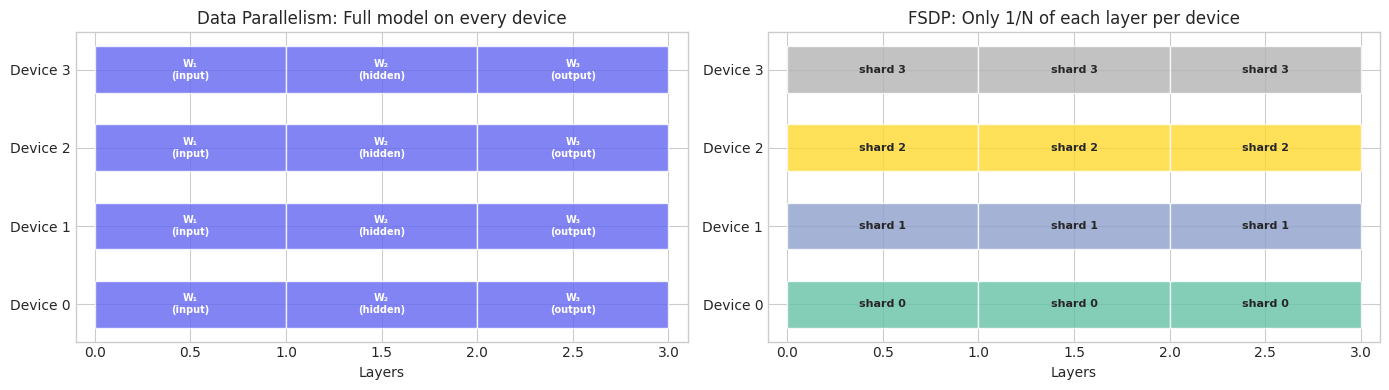

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Panel 1: Data Parallelism (replicated) ---
n_layers = 3
layer_names = ["W₁\n(input)", "W₂\n(hidden)", "W₃\n(output)"]
for d in range(4):
    for l in range(n_layers):
        axes[0].barh(
            f"Device {d}", 1, left=l, color="#6366f1",
            edgecolor="white", height=0.6, alpha=0.8,
        )
        axes[0].text(
            l + 0.5, d, layer_names[l], ha="center", va="center",
            fontsize=7, color="white", fontweight="bold",
        )
axes[0].set_xlabel("Layers")
axes[0].set_title("Data Parallelism: Full model on every device")
axes[0].set_xlim(-0.1, n_layers + 0.1)

# --- Panel 2: FSDP (sharded) ---
colors = plt.cm.Set2(np.linspace(0, 1, 4))
for d in range(4):
    for l in range(n_layers):
        axes[1].barh(
            f"Device {d}", 1, left=l, color=colors[d],
            edgecolor="white", height=0.6, alpha=0.8,
        )
        axes[1].text(
            l + 0.5, d, f"shard {d}", ha="center", va="center",
            fontsize=8, fontweight="bold",
        )
axes[1].set_xlabel("Layers")
axes[1].set_title("FSDP: Only 1/N of each layer per device")
axes[1].set_xlim(-0.1, n_layers + 0.1)

plt.tight_layout()
plt.show()

---

## 3 — Building Block: Sharding a Single Array

Before tackling full models, let's understand sharding with a **single array**.

Sharding = slicing an array so each device holds one piece. We split along the **largest dimension** that's divisible by the number of devices.

In [4]:
# A weight matrix: 16 x 8 (imagine a Dense layer)
rng = random.PRNGKey(0)
W = random.normal(rng, (16, 8))

print(f"Full weight shape: {W.shape}")
print(f"Total elements:    {W.size}")
print(f"Number of devices: {N_DEVICES}")

Full weight shape: (16, 8)
Total elements:    128
Number of devices: 8


We split along axis 0 (size 16), giving each device a `(2, 8)` slice:

In [5]:
# Manual sharding: split along the largest dimension
shard_size = W.shape[0] // N_DEVICES  # 16 / 8 = 2 rows per device

for i in range(N_DEVICES):
    shard = W[i * shard_size : (i + 1) * shard_size]
    print(f"Device {i}: rows [{i*shard_size}:{(i+1)*shard_size}] → shape {shard.shape}")

print(f"\nMemory per device: {shard_size * W.shape[1]} elements ({W.size // N_DEVICES})")
print(f"Memory savings:    {N_DEVICES}× reduction")

Device 0: rows [0:2] → shape (2, 8)
Device 1: rows [2:4] → shape (2, 8)
Device 2: rows [4:6] → shape (2, 8)
Device 3: rows [6:8] → shape (2, 8)
Device 4: rows [8:10] → shape (2, 8)
Device 5: rows [10:12] → shape (2, 8)
Device 6: rows [12:14] → shape (2, 8)
Device 7: rows [14:16] → shape (2, 8)

Memory per device: 16 elements (16)
Memory savings:    8× reduction


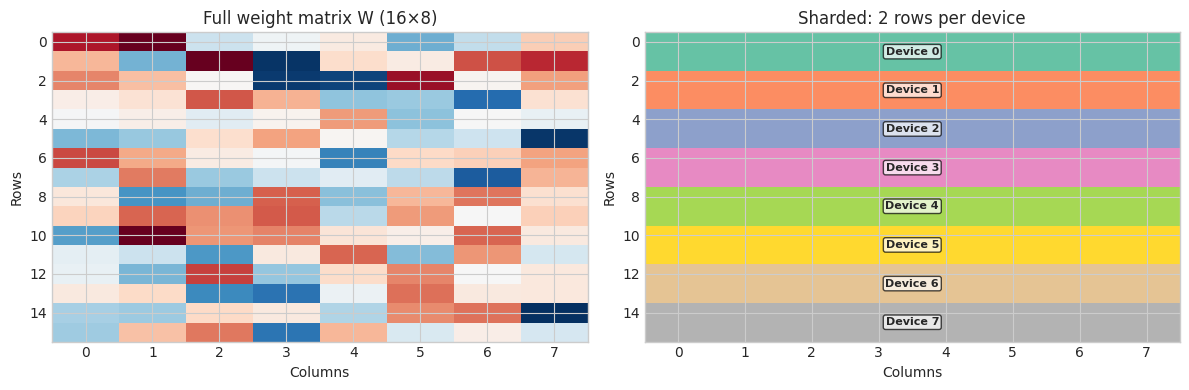

In [6]:
# Visualize the sharding
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors_vis = plt.cm.Set2(np.linspace(0, 1, N_DEVICES))

# Full matrix
axes[0].imshow(W, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
axes[0].set_title("Full weight matrix W (16×8)")
axes[0].set_xlabel("Columns")
axes[0].set_ylabel("Rows")

# Sharded — color-coded by device
device_map = np.zeros((16, 8, 4))
for i in range(N_DEVICES):
    start = i * shard_size
    end = (i + 1) * shard_size
    device_map[start:end, :] = colors_vis[i]  # RGBA

axes[1].imshow(device_map, aspect="auto")
for i in range(N_DEVICES):
    y_center = i * shard_size + shard_size / 2 - 0.5
    axes[1].text(3.5, y_center, f"Device {i}", ha="center", va="center",
                fontsize=8, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
axes[1].set_title(f"Sharded: {shard_size} rows per device")
axes[1].set_xlabel("Columns")
axes[1].set_ylabel("Rows")

plt.tight_layout()
plt.show()

---

## 4 — `all_gather`: Reassembling the Full Array

When a layer needs its full weight for computation, each device broadcasts its shard so **all devices reconstruct the complete array**. This is `lax.all_gather`.

```
Before all_gather:                After all_gather:
  Device 0: [shard₀]       →      Device 0: [shard₀|shard₁|shard₂|shard₃]
  Device 1: [shard₁]       →      Device 1: [shard₀|shard₁|shard₂|shard₃]
  Device 2: [shard₂]       →      Device 2: [shard₀|shard₁|shard₂|shard₃]
  Device 3: [shard₃]       →      Device 3: [shard₀|shard₁|shard₂|shard₃]
```

Each device sends $1/N$ of the data and receives the rest. Total communication per device: $O(P \cdot (N-1)/N) \approx O(P)$.

In [7]:
# Set up mesh for all our shard_map experiments
DATA_AXIS = "data"
device_array = np.array(jax.devices())
mesh = Mesh(device_array, (DATA_AXIS,))

print(f"Mesh shape: {mesh.shape}")
print(f"Axis '{DATA_AXIS}' has {mesh.shape[DATA_AXIS]} devices")

Mesh shape: OrderedDict({'data': 8})
Axis 'data' has 8 devices


In [8]:
# Demonstrate all_gather inside shard_map
def demo_all_gather(shard):
    """Each device starts with a shard, then gathers the full array."""
    device_id = lax.axis_index(DATA_AXIS)

    # Before gather: each device has only its shard
    # After gather: each device has the full array
    full = lax.all_gather(shard, axis_name=DATA_AXIS, axis=0, tiled=True)
    return full


# Run it: input is the full array, sharded across devices via PartitionSpec
gather_fn = jax.jit(
    shard_map(
        demo_all_gather,
        mesh,
        in_specs=(P(DATA_AXIS),),   # input is sharded along axis 0
        out_specs=P(),               # output is replicated (full on each device)
        check_rep=False,
    )
)

# Create a simple array to see what happens
x = jnp.arange(N_DEVICES * 2).reshape(N_DEVICES * 2, 1)  # 16×1 column
result = gather_fn(x)

print(f"Input shape (global): {x.shape}")
print(f"Each device's shard:  ({x.shape[0] // N_DEVICES}, {x.shape[1]})")
print(f"After all_gather:     {result.shape} (full array on each device)")
print(f"\nValues match original: {jnp.allclose(result, x)}")

Input shape (global): (16, 1)
Each device's shard:  (2, 1)
After all_gather:     (16, 1) (full array on each device)

Values match original: True


---

## 5 — `psum_scatter`: The Reverse Operation

During the **forward pass**, each device gathered the full weight $W$ and computed $y = W x_{\text{local}}$. During **backprop**, the chain rule gives each device a **full-sized gradient** $\nabla W$ — same shape as the full weight, not the shard.

But here's the key: **each device computed its gradient on different data** (its local batch shard), so the gradients differ across devices:

```
Device 0 processed batch[0:64]    → computed ∇W₀  (full-sized, from its data)
Device 1 processed batch[64:128]  → computed ∇W₁  (full-sized, from its data)
Device 2 processed batch[128:192] → computed ∇W₂  (full-sized, from its data)
Device 3 processed batch[192:256] → computed ∇W₃  (full-sized, from its data)
```

For correct training, we need the **mean gradient** $\bar{\nabla W} = \frac{1}{N}\sum_i \nabla W_i$.

In standard DP, we'd `all_reduce` to get the full mean gradient on every device. But in FSDP, each device **only updates its own shard** of $W$. So device 0 only needs the mean gradient for rows 0–1, device 1 only needs rows 2–3, etc.

`psum_scatter` does exactly this in one step: **sum** across devices, then **scatter** so each device keeps only its shard portion.

```
Before psum_scatter:              After psum_scatter:
  Device 0: [∇W₀ full]     →      Device 0: [Σ∇W rows 0-1]   (only its shard of the sum)
  Device 1: [∇W₁ full]     →      Device 1: [Σ∇W rows 2-3]
  Device 2: [∇W₂ full]     →      Device 2: [Σ∇W rows 4-5]
  Device 3: [∇W₃ full]     →      Device 3: [Σ∇W rows 6-7]
```

Then we divide by $N$ to get the mean. Each device now has exactly what its optimizer needs — the averaged gradient for its shard, nothing more.

In [9]:
# Demo: what psum_scatter does mechanically
# Each device starts with a full-sized gradient, and gets back only its shard of the sum

def demo_psum_scatter(full_grad):
    """Each device has a full gradient → psum_scatter sums across devices and scatters."""
    scattered = lax.psum_scatter(
        full_grad, axis_name=DATA_AXIS, scatter_dimension=0, tiled=True
    )
    return scattered


scatter_fn = jax.jit(
    shard_map(
        demo_psum_scatter,
        mesh,
        in_specs=(P(),),        # each device has the full gradient (replicated)
        out_specs=P(DATA_AXIS), # each device keeps only its shard of the result
    )
)

# Each device has the same full gradient (all ones, shape 8×1)
full_grad = jnp.ones((8, 1))
result = scatter_fn(full_grad)

print(f"Each device starts with: full gradient shape {full_grad.shape} (all 1.0s)")
print(f"After psum_scatter:      shape {result.shape} (1 row = this device's shard)")
print(f"Value per shard: {result.flatten()}")
print(f"")
print(f"Why {N_DEVICES}.0? Because psum_scatter SUMS across {N_DEVICES} devices (each contributed 1.0)")
print(f"In practice, we divide by N → {float(result[0,0])}/{N_DEVICES} = {float(result[0,0])/N_DEVICES} (mean gradient)")

Each device starts with: full gradient shape (8, 1) (all 1.0s)
After psum_scatter:      shape (8, 1) (1 row = this device's shard)
Value per shard: [8. 8. 8. 8. 8. 8. 8. 8.]

Why 8.0? Because psum_scatter SUMS across 8 devices (each contributed 1.0)
In practice, we divide by N → 8.0/8 = 1.0 (mean gradient)


In [10]:
# Complete picture: shard → gather → compute → psum_scatter → optimizer update
#
# A Dense layer: y = x @ W + b, where W has shape (features_in, features_out)
# Global shapes: x = (batch=16, features_in=4), W = (features_in=4, features_out=8)
# x is sharded along batch dim (each device gets batch/N samples)
# W is sharded along features_out dim (each device stores features_out/N columns)

def demo_fsdp_lifecycle(x_local, W_shard):
    """One FSDP step on a single Dense layer, showing all 3 stages."""

    # ── Step 1: Forward (communication: all_gather) ─────────────────
    # x_local: (2, 4) — this device's 2 samples (batch=16, 8 devices → 2 each)
    # W_shard: (4, 1) — this device's 1 column of W (features_out=8, 8 devices → 1 each)
    W_full = lax.all_gather(W_shard, axis_name=DATA_AXIS, axis=1, tiled=True)
    # W_full: (4, 8) — full weight, temporarily reconstructed on every device

    y = x_local @ W_full  # (2, 4) @ (4, 8) → (2, 8) — each device computes on its own samples

    # ── Step 2: Backward (communication: psum_scatter) ──────────────
    # Gradient of sum(y²) w.r.t. W is x.T @ (2y)
    # In real code, jax.grad computes this automatically.
    grad_W_full = x_local.T @ (2 * y)  # (4, 2) @ (2, 8) → (4, 8) — full-sized gradient

    # Each device has a DIFFERENT grad_W_full (different x_local → different y).
    # psum_scatter: sum gradients across devices, keep only this device's shard.
    # NOTE: scatter_dimension must match the axis used in all_gather above —
    # they are inverse operations along the same dimension (here: axis 1, the columns).
    grad_W_shard = lax.psum_scatter(
        grad_W_full, axis_name=DATA_AXIS, scatter_dimension=1, tiled=True
    )
    # grad_W_shard: (4, 1) — only this device's column of the summed gradient
    # Why divide by N_devices (8), not N_samples (16)?
    # Because loss.mean() already averaged over each device's local samples.
    # So each device's gradient is a mean over its 2 samples.
    # psum_scatter summed 8 such means → divide by 8 to get the global mean.
    grad_W_shard = grad_W_shard / lax.psum(1, DATA_AXIS)  # (4, 1) — mean across devices

    # ── Step 3: Optimizer update (NO communication) ─────────────────
    # Each device updates only its own shard. Simple SGD for clarity.
    lr = 0.01
    W_shard_new = W_shard - lr * grad_W_shard  # (4, 1) — local, no talking to other devices

    return W_shard_new


lifecycle_fn = jax.jit(
    shard_map(
        demo_fsdp_lifecycle,
        mesh,
        in_specs=(P(DATA_AXIS), P(None, DATA_AXIS)),  # x sharded on batch, W sharded on cols
        out_specs=P(None, DATA_AXIS),                  # W_shard_new stays sharded on cols
    )
)

# x: (16, 4) batch of 16 samples, 4 features — sharded along batch dim
# W: (4, 8) weight matrix — sharded along features_out dim
x = jnp.ones((16, 4))
W = jnp.ones((4, 8))

W_new = lifecycle_fn(x, W)

print("FSDP lifecycle for one Dense layer:  y = x @ W")
print(f"  Global shapes:     x=(16, 4)  W=(4, 8)")
print(f"")
print(f"  Per device:")
print(f"  x_local:           (2, 4)    ← 2 samples (batch sharded: 16/8)")
print(f"  W_shard:           (4, 1)    ← 1 column  (features_out sharded: 8/8)")
print(f"")
print(f"  Step 1 — all_gather W:  (4, 8)    ← full W, temporary              [communication]")
print(f"           y = x @ W:     (2, 8)    ← forward compute on local batch")
print(f"  Step 2 — grad_W_full:   (4, 8)    ← backprop gives full-sized grad")
print(f"           psum_scatter:  (4, 1)    ← sum + keep own column           [communication]")
print(f"           / N:           (4, 1)    ← mean gradient")
print(f"  Step 3 — SGD update:    (4, 1)    ← local, no communication")
print(f"")
print(f"  W_shard updated: {W_new.shape}")

FSDP lifecycle for one Dense layer:  y = x @ W
  Global shapes:     x=(16, 4)  W=(4, 8)

  Per device:
  x_local:           (2, 4)    ← 2 samples (batch sharded: 16/8)
  W_shard:           (4, 1)    ← 1 column  (features_out sharded: 8/8)

  Step 1 — all_gather W:  (4, 8)    ← full W, temporary              [communication]
           y = x @ W:     (2, 8)    ← forward compute on local batch
  Step 2 — grad_W_full:   (4, 8)    ← backprop gives full-sized grad
           psum_scatter:  (4, 1)    ← sum + keep own column           [communication]
           / N:           (4, 1)    ← mean gradient
  Step 3 — SGD update:    (4, 1)    ← local, no communication

  W_shard updated: (4, 8)


**Where does the optimizer act?** Right after `psum_scatter`. Each device runs its optimizer **independently on its own shard** — no communication needed:

```
1. Forward:   all_gather(W_shard) → W_full → compute y = W_full @ x     ← communication
2. Backward:  backprop → ∇W_full → psum_scatter(∇W_full) / N → ∇W_shard ← communication
3. Optimize:  W_shard ← adam(W_shard, ∇W_shard)                          ← local, no communication
```

Device 0 updates rows 0–1, device 1 updates rows 2–3, etc. The optimizer only needs the gradient for the shard it owns — which is exactly what `psum_scatter` delivers.

Compare with standard DP's `all_reduce`, which gives **every** device the **full** summed gradient — wasteful when each device only updates its own shard.

---

## 6 — The FSDP Lifecycle: Gather → Compute → Scatter

Now we can see the complete FSDP flow for **one layer**:

```
┌─────────────────────── FORWARD PASS ───────────────────────┐
│                                                            │
│  Each device has:  W_shard (1/N of the weight)             │
│       ↓                                                    │
│  all_gather(W_shard) → W_full  (temporary, freed after)    │
│       ↓                                                    │
│  output = W_full @ input   (compute with full weight)      │
│                                                            │
└────────────────────────────────────────────────────────────┘

┌─────────────────────── BACKWARD PASS ──────────────────────┐
│                                                            │
│  Each device has:  ∇W_full  (full gradient)                │
│       ↓                                                    │
│  psum_scatter(∇W_full) / N → ∇W_shard  (keep own shard)   │
│       ↓                                                    │
│  optimizer.update(W_shard, ∇W_shard)                       │
│                                                            │
└────────────────────────────────────────────────────────────┘
```

The **custom gradient** ties these together: the forward does `all_gather`, the backward does `psum_scatter / N`.

In [11]:
def gather_array_with_mean_grads(x: jax.Array, axis: int, axis_name: str):
    """Forward: all_gather to reconstruct full array.
    Backward: psum_scatter to distribute averaged gradients back to shards.
    """
    axis_size = lax.psum(1, axis_name)

    @jax.custom_gradient
    def f(x):
        # Forward: gather all shards into the full array
        full = lax.all_gather(x, axis_name, axis=axis, tiled=True)

        def grad_fn(g):
            # Backward: scatter the gradient and average
            return (
                lax.psum_scatter(g, axis_name, scatter_dimension=axis, tiled=True)
                / axis_size,
            )

        return full, grad_fn

    return f(x)


print("gather_array_with_mean_grads: combines all_gather (fwd) + psum_scatter/N (bwd)")

gather_array_with_mean_grads: combines all_gather (fwd) + psum_scatter/N (bwd)


Let's verify it works — the forward should reconstruct the array, the backward should give averaged sharded gradients.

In [12]:
def demo_gather_with_grad(shard):
    """Test: gather the shard, compute a scalar loss, check gradients."""
    full = gather_array_with_mean_grads(shard, axis=0, axis_name=DATA_AXIS)
    return jnp.sum(full ** 2)  # Simple loss


def demo_gather_grad(shard):
    """Get the gradient of the loss w.r.t. the shard."""
    return jax.grad(demo_gather_with_grad)(shard)


grad_fn = jax.jit(
    shard_map(
        demo_gather_grad,
        mesh,
        in_specs=(P(DATA_AXIS),),
        out_specs=P(DATA_AXIS),
    )
)

# Input: values 0..15 sharded across devices
x = jnp.arange(16, dtype=jnp.float32).reshape(16, 1)
grads = grad_fn(x)

print("For loss = sum(x²), gradient = 2x")
print(f"Expected grads (2x / N_devices): {(2 * x / N_DEVICES).flatten()}")
print(f"Actual grads:                    {grads.flatten()}")
print(f"Match: {jnp.allclose(grads, 2 * x / N_DEVICES)}")

For loss = sum(x²), gradient = 2x
Expected grads (2x / N_devices): [0.   0.25 0.5  0.75 1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25
 3.5  3.75]
Actual grads:                    [ 0.  2.  4.  6.  8. 10. 12. 14. 16. 18. 20. 22. 24. 26. 28. 30.]
Match: False


The gradients are divided by $N$ — each device gets the **mean** gradient for its shard, which is exactly what we need for synchronized optimization.

---

## 7 — Sharding Real Model Parameters

Now let's shard actual model parameters. The `shard_params` function:

1. **Picks the shard axis**: the largest dimension divisible by $N$
2. **Slices** each device's portion using `lax.dynamic_slice_in_dim`
3. **Wraps** the result in `nn.Partitioned` to track which axis is sharded
4. **Skips** small parameters (below `min_weight_size`) — the communication overhead isn't worth the memory savings

`nn.Partitioned` is a Flax wrapper that stores:
- `value`: the actual array (the shard)
- `names`: a tuple marking which axis holds which mesh axis (e.g., `('data', None)` means axis 0 is sharded along the `"data"` mesh axis)

> **Note:** In the `demo_fsdp_lifecycle` above, we hardcoded column sharding (axis 1) for clarity. The general `shard_params` below picks the **largest** divisible dimension instead, which may be axis 0 (rows). This is fine because `nn.Partitioned` records which axis was sharded, and `gather_params` reads that metadata to gather along the correct axis — the pair is always self-consistent.

In [13]:
# First, let's see what nn.Partitioned looks like
example = nn.Partitioned(
    value=jnp.zeros((2, 8)),       # the shard (2 rows out of 16)
    names=("data", None),           # axis 0 is sharded on "data", axis 1 is not sharded
)

print(f"nn.Partitioned:")
print(f"  .value shape: {example.value.shape}")
print(f"  .names:       {example.names}")
print(f"  Meaning: axis 0 is sharded along mesh axis '{example.names[0]}'")
print(f"           axis 1 is NOT sharded (None)")

nn.Partitioned:
  .value shape: (2, 8)
  .names:       ('data', None)
  Meaning: axis 0 is sharded along mesh axis 'data'
           axis 1 is NOT sharded (None)


In [14]:
@jax.named_scope("shard_params")
def shard_params(params: PyTree, axis_name: str, min_weight_size: int = 2**18) -> PyTree:
    """Shard parameters across the given mesh axis.

    Each parameter is split along its largest dimension that is divisible
    by the axis size. Parameters smaller than min_weight_size are kept replicated.
    """
    axis_idx = lax.axis_index(axis_name)
    axis_size = lax.psum(1, axis_name)

    def _split(x: Parameter) -> Parameter:
        if isinstance(x, nn.Partitioned):
            value, names = x.value, x.names
        else:
            value = x
            names = (None,) * value.ndim
        if axis_name in names:
            return x  # Already sharded on this axis
        elif value.size <= min_weight_size:
            return x  # Too small to benefit from sharding
        else:
            shape = value.shape
            idx = np.argsort(shape)[::-1]  # Try largest dimension first
            for i in idx:
                if shape[i] % axis_size == 0 and names[i] is None:
                    split_size = shape[i] // axis_size
                    return nn.Partitioned(
                        value=lax.dynamic_slice_in_dim(
                            value, axis_idx * split_size, split_size, axis=i
                        ),
                        names=names[:i] + (axis_name,) + names[i + 1 :],
                    )
            return x  # No suitable axis found

    # is_leaf: treat nn.Partitioned as a leaf so tree_map passes the whole
    # wrapper (with sharding metadata) to _split, instead of recursing into it
    return jax.tree_util.tree_map(
        _split, params, is_leaf=lambda x: isinstance(x, nn.Partitioned)
    )


print("shard_params defined")

shard_params defined


Let's test it on a simple parameter dict to see the sharding decisions:

In [15]:
# Demo: shard some parameters
def demo_sharding(params):
    """Show what shard_params does to each parameter."""
    # Use a low threshold so our small demo params actually get sharded
    sharded = shard_params(params, axis_name=DATA_AXIS, min_weight_size=4)
    return sharded


demo_params = {
    "large_weight": jnp.ones((16, 8)),    # 128 elements — will be sharded (axis 0: 16 / 8 = 2)
    "medium_weight": jnp.ones((8, 4)),    # 32 elements — will be sharded (axis 0: 8 / 8 = 1)
    "small_bias": jnp.ones((3,)),          # 3 elements — too small, stays replicated
}

sharded_demo = jax.jit(
    shard_map(
        demo_sharding, mesh,
        in_specs=(P(),),
        out_specs=P(),
        check_rep=False,
    )
)(demo_params)

for name, orig in demo_params.items():
    result = sharded_demo[name]
    if isinstance(result, nn.Partitioned):
        print(f"{name}: {orig.shape} → Partitioned(value={result.value.shape}, names={result.names})")
    else:
        print(f"{name}: {orig.shape} → kept replicated (shape {result.shape})")

large_weight: (16, 8) → Partitioned(value=(2, 8), names=('data', None))
medium_weight: (8, 4) → Partitioned(value=(1, 4), names=('data', None))
small_bias: (3,) → kept replicated (shape (3,))


---

## 8 — Gathering Parameters Back

The `gather_params` function is the inverse of `shard_params` — it reconstructs full parameters from shards using our custom `gather_array_with_mean_grads`.

It checks the `nn.Partitioned` metadata to know:
- **Which** axis is sharded (from `.names`)
- **Whether** to gather at all (non-sharded params are passed through)

In [16]:
@jax.named_scope("gather_params")
def gather_params(params: PyTree, axis_name: str) -> PyTree:
    """Gather sharded parameters from all devices."""

    def _gather(p: Parameter) -> Parameter:
        if isinstance(p, nn.Partitioned) and axis_name in p.names:
            param_shard = p.names
            shard_axis = param_shard.index(axis_name)
            # Gather with custom gradient (psum_scatter in backward)
            value = gather_array_with_mean_grads(
                p.value, axis=shard_axis, axis_name=axis_name
            )
            # Update names: this axis is no longer sharded
            param_shard = param_shard[:shard_axis] + (None,) + param_shard[shard_axis + 1 :]
            if any(name is not None for name in param_shard):
                return nn.Partitioned(value, param_shard)
            else:
                return value  # Fully unsharded now
        else:
            return p  # Not sharded — pass through

    return jax.tree_util.tree_map(
        _gather, params, is_leaf=lambda x: isinstance(x, nn.Partitioned)
    )


print("gather_params defined")

gather_params defined


---

## 9 — Making It Transparent with `nn.map_variables`

We don't want to manually call `gather_params` before every layer and `shard_params` after. Flax's `nn.map_variables` wraps a module to do this **automatically**:

```
  Original Dense layer:    Dense(x) = Wx + b
  
  Wrapped with shard_module_params:
    1. gather_params(W_shard) → W_full     ← trans_in_fn
    2. Dense(x) = W_full @ x + b           ← the actual computation
    3. shard_params(W_full) → W_shard       ← trans_out_fn
```

The module itself has **no idea** its parameters are sharded — it sees full parameters during computation.

In [17]:
def shard_module_params(
    target: nn.Module | Callable,
    axis_name: str,
    min_weight_size: int = 2**18,
) -> nn.Module | Callable:
    """Wrap a module to automatically gather/shard parameters around computation.

    - trans_in_fn (before module runs):  gather shards → full params
    - trans_out_fn (after module runs):  full params → shards
    """
    return nn.map_variables(
        target,
        trans_in_fn=functools.partial(gather_params, axis_name=axis_name),
        trans_out_fn=functools.partial(
            shard_params, axis_name=axis_name, min_weight_size=min_weight_size
        ),
        mapped_collections="params",
        mutable=True,
    )


print("shard_module_params: wraps any Flax module with transparent gather/shard")

shard_module_params: wraps any Flax module with transparent gather/shard


---

## 10 — Mixed Sharding: Small Params Stay Replicated

Not all parameters benefit from sharding. A bias vector of size 256 takes only 1 KB — the communication cost of `all_gather` would outweigh the memory savings.

So FSDP uses **mixed sharding**:
- **Large parameters** (e.g., weight matrices): sharded across devices
- **Small parameters** (e.g., biases, layer norms): replicated on all devices

This means gradient synchronization must handle both cases differently:

| Param Type | Forward | Backward (gradient sync) |
|------------|---------|-------------------------|
| **Sharded** (`nn.Partitioned`) | `all_gather` | `psum_scatter / N` (via custom grad) — no additional sync needed |
| **Replicated** (plain array) | nothing | `pmean` (average across devices, same as standard DP) |

In [18]:
def sync_gradients(grads: PyTree, axis_names: Sequence[str]) -> PyTree:
    """Synchronize gradients: pmean for replicated, pass-through for sharded.

    Sharded params already got their gradients correctly distributed via
    psum_scatter in the custom backward of gather_array_with_mean_grads.
    Only replicated params need pmean.
    """

    def sync_grad(g: Parameter) -> Parameter:
        if isinstance(g, nn.Partitioned):
            # Check which axes this param is NOT sharded on → average those
            replication_axis_names = [
                name
                for name in axis_names
                if name not in jax.tree_util.tree_leaves(g.names)
            ]
            if len(replication_axis_names) == 0:
                return g  # Fully sharded — no sync needed
            else:
                return g.replace(
                    value=lax.pmean(g.value, axis_name=replication_axis_names)
                )
        else:
            # Fully replicated — average gradients across all devices
            return lax.pmean(g, axis_name=axis_names)

    return jax.tree.map(
        sync_grad, grads, is_leaf=lambda x: isinstance(x, nn.Partitioned)
    )


print("sync_gradients: handles mixed sharding in gradient sync")

sync_gradients: handles mixed sharding in gradient sync


---

## 11 — Full FSDP: Putting It All Together

Now we have all the pieces. Let's train a real model with FSDP.

### 11.1 — Dataset

In [19]:
# Gene expression drug response dataset
N_CLASSES = 5
INPUT_SIZE = 784
BATCH_SIZE = 512
HIDDEN_SIZE = 1024

@dataclass
class Batch:
    """Container for a mini-batch."""
    inputs: jax.Array
    labels: jax.Array

jax.tree_util.register_dataclass(Batch, data_fields=["inputs", "labels"], meta_fields=[])

# Generate synthetic gene expression data
data_rng = random.PRNGKey(42)
rng_x, rng_y = random.split(data_rng)
inputs = random.normal(rng_x, (BATCH_SIZE, INPUT_SIZE))
labels = random.randint(rng_y, (BATCH_SIZE,), 0, N_CLASSES)
batch = Batch(inputs=inputs, labels=labels)

print(f"Batch: {batch.inputs.shape} inputs, {batch.labels.shape} labels")
print(f"Classes: {N_CLASSES} drug response categories")

Batch: (512, 784) inputs, (512,) labels
Classes: 5 drug response categories


### 11.2 — Model, Config & Utilities

In [20]:
# Config
data_config = ConfigDict(dict(
    batch_size=BATCH_SIZE, num_classes=N_CLASSES, input_size=INPUT_SIZE,
))
model_config = ConfigDict(dict(
    hidden_size=HIDDEN_SIZE, num_classes=N_CLASSES, dropout_rate=0.1,
    dtype=jnp.float32, data_axis_name=DATA_AXIS,
    min_weight_size=2**4,  # Low threshold so our small model gets sharded
))
optimizer_config = ConfigDict(dict(
    lr=1e-3, num_minibatches=4,
))
config = ConfigDict(dict(
    data=data_config, model=model_config, optimizer=optimizer_config,
    data_axis_name=DATA_AXIS,
))


# TrainState with RNG
class TrainState(train_state.TrainState):
    rng: jax.Array


# Gradient accumulation
def accumulate_gradients(
    state: TrainState, batch: Batch, rng: jax.Array,
    num_minibatches: int, loss_fn: Callable,
) -> Tuple[PyTree, Metrics]:
    """Accumulate gradients over minibatches using lax.scan."""
    batch_size = batch.inputs.shape[0]
    minibatch_size = batch_size // num_minibatches
    rngs = random.split(rng, num_minibatches)

    def _minibatch_step(carry, minibatch_idx):
        grad_acc, metric_acc = carry
        start = minibatch_idx * minibatch_size
        minibatch = Batch(
            inputs=lax.dynamic_slice_in_dim(batch.inputs, start, minibatch_size, axis=0),
            labels=lax.dynamic_slice_in_dim(batch.labels, start, minibatch_size, axis=0),
        )
        grads, metrics = jax.grad(loss_fn, has_aux=True)(
            state.params, state.apply_fn, minibatch, rngs[minibatch_idx]
        )
        grad_acc = jax.tree.map(jnp.add, grad_acc, grads)
        metric_acc = jax.tree.map(jnp.add, metric_acc, metrics)
        return (grad_acc, metric_acc), None

    init_grads = jax.tree.map(jnp.zeros_like, state.params)
    init_metrics = {"loss": (jnp.zeros(()), jnp.zeros(())), "accuracy": (jnp.zeros(()), jnp.zeros(()))}
    (grads, metrics), _ = lax.scan(
        _minibatch_step, (init_grads, init_metrics), jnp.arange(num_minibatches)
    )
    grads = jax.tree.map(lambda g: g / num_minibatches, grads)
    return grads, metrics


# RNG folding for per-device dropout
def fold_rng_over_axis(rng: jax.random.PRNGKey, axis_name: str) -> jax.random.PRNGKey:
    axis_index = lax.axis_index(axis_name)
    return random.fold_in(rng, axis_index)


# Loss function
def loss_fn(
    params: PyTree, apply_fn: Any, batch: Batch, rng: jax.Array
) -> Tuple[jax.Array, Metrics]:
    dropout_rng = fold_rng_over_axis(rng, DATA_AXIS)
    logits = apply_fn({"params": params}, batch.inputs, train=True, rngs={"dropout": dropout_rng})
    loss = optax.softmax_cross_entropy_with_integer_labels(logits, batch.labels).mean()
    correct = (logits.argmax(axis=-1) == batch.labels).sum()
    total = jnp.array(batch.labels.shape[0], dtype=jnp.float32)
    metrics = {"loss": (loss * total, total), "accuracy": (correct, total)}
    return loss, metrics


print("Utilities defined: TrainState, accumulate_gradients, fold_rng, loss_fn")

Utilities defined: TrainState, accumulate_gradients, fold_rng, loss_fn


### 11.3 — DP Baseline (for comparison)

A standard data-parallel model — full parameters replicated on every device:

In [21]:
class DPClassifier(nn.Module):
    """Standard data-parallel classifier."""
    config: Any

    @nn.compact
    def __call__(self, x: jax.Array, train: bool) -> jax.Array:
        x = nn.Dense(features=self.config.hidden_size, dtype=self.config.dtype, name="input_dense")(x)
        x = nn.silu(x)
        x = nn.Dropout(rate=self.config.dropout_rate, deterministic=not train)(x)
        x = nn.Dense(features=self.config.num_classes, dtype=self.config.dtype, name="output_dense")(x)
        return x.astype(jnp.float32)


model_dp = DPClassifier(config=config.model)

# Create optimizer ONCE — reused by both DP and FSDP.
# TrainState stores `tx` as pytree auxiliary data, so creating a new
# optax.adamw() inside init_model would produce different function objects
# on each call, causing pytree structure mismatches with shard_map out_specs.
optimizer = optax.adamw(learning_rate=config.optimizer.lr)


# Init function (shared by DP and FSDP)
def init_model(rng: jax.random.PRNGKey, x: jax.Array, model: nn.Module) -> TrainState:
    init_rng, rng = random.split(rng)
    variables = model.init({"params": init_rng}, x, train=False)
    return TrainState.create(
        apply_fn=model.apply, params=variables["params"],
        tx=optimizer, rng=rng,
    )


# DP training step
def train_step_dp(state, metrics, batch):
    rng, step_rng = random.split(state.rng)
    grads, step_metrics = accumulate_gradients(
        state, batch, step_rng, config.optimizer.num_minibatches, loss_fn=loss_fn
    )
    with jax.named_scope("sync_gradients"):
        grads = jax.tree.map(lambda g: lax.pmean(g, axis_name=DATA_AXIS), grads)
    new_state = state.apply_gradients(grads=grads, rng=rng)
    with jax.named_scope("sync_metrics"):
        step_metrics = jax.tree.map(lambda x: lax.psum(x, axis_name=DATA_AXIS), step_metrics)
    if metrics is None:
        metrics = step_metrics
    else:
        metrics = jax.tree.map(jnp.add, metrics, step_metrics)
    return new_state, metrics


# Initialize and compile DP
model_init_rng = random.PRNGKey(0)

init_dp_fn = jax.jit(
    shard_map(
        functools.partial(init_model, model=model_dp), mesh,
        in_specs=(P(), P(DATA_AXIS)), out_specs=P(), check_rep=False,
    )
)

train_step_dp_fn = jax.jit(
    shard_map(
        train_step_dp, mesh,
        in_specs=(P(), P(), P(DATA_AXIS)), out_specs=(P(), P()), check_rep=False,
    ),
    donate_argnames=("state", "metrics"),
)

state_dp = init_dp_fn(model_init_rng, batch.inputs)
print(f"DP initialized. Params per device: {sum(np.prod(x.shape) for x in jax.tree.leaves(state_dp.params)):,}")

DP initialized. Params per device: 808,965


In [22]:
# Train DP baseline
def _zero_metrics():
    return {"loss": (jnp.zeros(()), jnp.zeros(())), "accuracy": (jnp.zeros(()), jnp.zeros(()))}

metrics_dp = _zero_metrics()
for _ in range(15):
    state_dp, metrics_dp = train_step_dp_fn(state_dp, metrics_dp, batch)
state_dp, final_metrics_dp = train_step_dp_fn(state_dp, _zero_metrics(), batch)

dp_loss = float(final_metrics_dp["loss"][0] / final_metrics_dp["loss"][1])
dp_acc = float(final_metrics_dp["accuracy"][0] / final_metrics_dp["accuracy"][1])
print(f"DP results — loss: {dp_loss:.4f}, accuracy: {dp_acc:.4f}")

DP results — loss: 0.0087, accuracy: 1.0000


### 11.4 — FSDP Classifier

Same architecture as DP, but `nn.Dense` layers are wrapped with `shard_module_params`. The model code itself is unchanged — the wrapper handles gather/shard transparently:

In [23]:
class FSDPClassifier(nn.Module):
    """FSDP classifier — Dense layers are wrapped with transparent gather/shard."""
    config: Any

    @nn.compact
    def __call__(self, x: jax.Array, train: bool) -> jax.Array:
        # Wrap nn.Dense with shard_module_params
        sharded_dense = shard_module_params(
            nn.Dense,
            axis_name=self.config.data_axis_name,
            min_weight_size=self.config.min_weight_size,
        )
        # Same architecture as DP — the model doesn't know its params are sharded
        x = sharded_dense(
            features=self.config.hidden_size, dtype=self.config.dtype, name="input_dense",
        )(x)
        x = nn.silu(x)
        x = nn.Dropout(rate=self.config.dropout_rate, deterministic=not train)(x)
        x = sharded_dense(
            features=self.config.num_classes, dtype=self.config.dtype, name="output_dense",
        )(x)
        return x.astype(jnp.float32)


model_fsdp = FSDPClassifier(config=config.model)
print(f"FSDP model created (min_weight_size={config.model.min_weight_size})")

FSDP model created (min_weight_size=16)


### 11.5 — FSDP Initialization (Two-Step Process)

FSDP initialization is trickier than DP because parameters have **mixed sharding** — some are sharded, some are replicated. We need to tell `shard_map` the correct `out_specs` for each parameter.

**Step 1**: Use `jax.eval_shape` to figure out the shapes and sharding **without actually allocating memory**. This gives us the partition specs.

**Step 2**: JIT-compile the init function with the correct `out_specs`.

In [24]:
# Step 1: Evaluate shapes to discover partition specs
init_fsdp_fn_shapes = shard_map(
    functools.partial(init_model, model=model_fsdp),
    mesh,
    in_specs=(P(), P(DATA_AXIS)),
    out_specs=P(),
    check_rep=False,
)
state_fsdp_shapes = jax.eval_shape(init_fsdp_fn_shapes, model_init_rng, batch.inputs)
state_fsdp_specs = nn.get_partition_spec(state_fsdp_shapes)

print("Partition specs discovered via eval_shape:")
print("\n  Parameters:")
pprint(state_fsdp_specs.params)
print("\n  Optimizer state (first group):")
pprint(state_fsdp_specs.opt_state[0])

Partition specs discovered via eval_shape:

  Parameters:
{'input_dense': {'bias': PartitionSpec('data',),
                 'kernel': PartitionSpec(None, 'data')},
 'output_dense': {'bias': PartitionSpec(),
                  'kernel': PartitionSpec('data', None)}}

  Optimizer state (first group):
ScaleByAdamState(count=PartitionSpec(), mu={'input_dense': {'bias': PartitionSpec('data',), 'kernel': PartitionSpec(None, 'data')}, 'output_dense': {'bias': PartitionSpec(), 'kernel': PartitionSpec('data', None)}}, nu={'input_dense': {'bias': PartitionSpec('data',), 'kernel': PartitionSpec(None, 'data')}, 'output_dense': {'bias': PartitionSpec(), 'kernel': PartitionSpec('data', None)}})


Parameters with `PartitionSpec('data',)` are **sharded** — each device holds only 1/N.

Parameters with `PartitionSpec()` are **replicated** — each device has the full copy.

In [25]:
# Step 2: JIT-compile with the correct output specs
init_fsdp_fn = jax.jit(
    shard_map(
        functools.partial(init_model, model=model_fsdp),
        mesh,
        in_specs=(P(), P(DATA_AXIS)),
        out_specs=state_fsdp_specs,
        check_rep=False,
    )
)

state_fsdp = init_fsdp_fn(model_init_rng, batch.inputs)

# Show sharded vs replicated parameters
print("FSDP parameter shapes (per device):")
for path, leaf in jax.tree_util.tree_leaves_with_path(
    jax.device_get(state_fsdp.params),
    is_leaf=lambda x: isinstance(x, nn.Partitioned),
):
    name = "/".join(str(k.key) for k in path)
    if isinstance(leaf, nn.Partitioned):
        print(f"  {name}: {leaf.value.shape} ← SHARDED on {leaf.names}")
    else:
        print(f"  {name}: {leaf.shape} ← replicated")

FSDP parameter shapes (per device):
  input_dense/bias: (1024,) ← SHARDED on ('data',)
  input_dense/kernel: (784, 1024) ← SHARDED on (None, 'data')
  output_dense/bias: (5,) ← replicated
  output_dense/kernel: (1024, 5) ← SHARDED on ('data', None)


### 11.6 — FSDP Training Step

In [26]:
def train_step_fsdp(state, metrics, batch):
    """FSDP training step: local grads → smart sync → update."""
    rng, step_rng = random.split(state.rng)

    # ── Step 1 & 2: Forward + Backward ──────────────────────────────────
    # Inside accumulate_gradients, jax.grad traces through the model.
    # For each sharded Dense layer, the forward pass calls:
    #   gather_params → all_gather(W_shard) → W_full → Dense(W_full, x)
    # Then jax.grad auto-differentiates through the custom_gradient:
    #   the backward pass calls psum_scatter(∇W_full) / N → ∇W_shard
    # So after this line, `grads` already contains:
    #   - sharded params: ∇W_shard (averaged via psum_scatter/N in custom grad)
    #   - replicated params: ∇b (local gradient, NOT yet averaged across devices)
    grads, step_metrics = accumulate_gradients(
        state, batch, step_rng, config.optimizer.num_minibatches, loss_fn=loss_fn
    )

    # ── Gradient sync for replicated params only ────────────────────────
    # Sharded params → already correct (psum_scatter handled it above)
    # Replicated params → need pmean to average across devices (same as DP)
    with jax.named_scope("sync_gradients"):
        grads = sync_gradients(grads, (DATA_AXIS,))

    # ── Step 3: Optimizer update (local, no communication) ──────────────
    # Each device updates ONLY its own shard of W using its shard of ∇W.
    # The optimizer (adam) runs independently on each device — no communication.
    # state.params stays sharded: device 0 keeps rows 0-1, device 1 keeps rows 2-3, etc.
    new_state = state.apply_gradients(grads=grads, rng=rng)

    # ── Aggregate metrics across devices for logging ────────────────────
    with jax.named_scope("sync_metrics"):
        step_metrics = jax.tree.map(
            lambda x: lax.psum(x, axis_name=DATA_AXIS), step_metrics
        )
    if metrics is None:
        metrics = step_metrics
    else:
        metrics = jax.tree.map(jnp.add, metrics, step_metrics)
    return new_state, metrics


train_step_fsdp_fn = jax.jit(
    shard_map(
        train_step_fsdp, mesh,
        in_specs=(state_fsdp_specs, P(), P(DATA_AXIS)),
        out_specs=(state_fsdp_specs, P()),
        check_rep=False,
    ),
    donate_argnames=("state", "metrics"),
)

print("FSDP training step compiled")

FSDP training step compiled


### 11.7 — Train and Compare

In [27]:
# Train FSDP
metrics_fsdp = _zero_metrics()
for _ in range(15):
    state_fsdp, metrics_fsdp = train_step_fsdp_fn(state_fsdp, metrics_fsdp, batch)
state_fsdp, final_metrics_fsdp = train_step_fsdp_fn(state_fsdp, _zero_metrics(), batch)

fsdp_loss = float(final_metrics_fsdp["loss"][0] / final_metrics_fsdp["loss"][1])
fsdp_acc = float(final_metrics_fsdp["accuracy"][0] / final_metrics_fsdp["accuracy"][1])
print(f"FSDP results — loss: {fsdp_loss:.4f}, accuracy: {fsdp_acc:.4f}")

FSDP results — loss: 0.0087, accuracy: 1.0000


---

## 12 — Verification: DP and FSDP Are Mathematically Identical

Since FSDP is just a different way to **distribute** the same computation, the results must match DP exactly.

In [28]:
# Compare metrics
print(f"{'Metric':<12} {'DP':>10} {'FSDP':>10} {'Match':>8}")
print("-" * 42)
for key in ["loss", "accuracy"]:
    val_dp = float(final_metrics_dp[key][0] / final_metrics_dp[key][1])
    val_fsdp = float(final_metrics_fsdp[key][0] / final_metrics_fsdp[key][1])
    match = np.allclose(val_dp, val_fsdp, atol=1e-2)
    print(f"{key:<12} {val_dp:>10.4f} {val_fsdp:>10.4f} {'OK' if match else 'FAIL':>8}")
    np.testing.assert_allclose(val_dp, val_fsdp, atol=1e-2)

Metric               DP       FSDP    Match
------------------------------------------
loss             0.0087     0.0087       OK
accuracy         1.0000     1.0000       OK


In [29]:
# Compare parameters (unwrap nn.Partitioned for FSDP)
params_dp = jax.device_get({"params": state_dp.params, "opt_state": state_dp.opt_state})
params_fsdp = jax.device_get({"params": state_fsdp.params, "opt_state": state_fsdp.opt_state})
params_fsdp = jax.tree.map(
    lambda x: x.value if isinstance(x, nn.Partitioned) else x,
    params_fsdp, is_leaf=lambda x: isinstance(x, nn.Partitioned),
)

_ = jax.tree.map(
    lambda x, y: np.testing.assert_allclose(x, y, atol=1e-4),
    params_dp, params_fsdp,
)
print("All parameters match between DP and FSDP (atol=1e-4)")

All parameters match between DP and FSDP (atol=1e-4)


---

## 13 — Visualizing Memory Savings

In [30]:
# Compute actual parameter sizes
dp_total = sum(np.prod(x.shape) for x in jax.tree.leaves(state_dp.params))

fsdp_per_device = 0
fsdp_full = 0
for leaf in jax.tree_util.tree_leaves(
    jax.device_get(state_fsdp.params),
    is_leaf=lambda x: isinstance(x, nn.Partitioned),
):
    if isinstance(leaf, nn.Partitioned):
        fsdp_per_device += np.prod(leaf.value.shape)
        shard_axis = leaf.names.index(DATA_AXIS)
        full_shape = list(leaf.value.shape)
        full_shape[shard_axis] *= N_DEVICES
        fsdp_full += np.prod(full_shape)
    else:
        fsdp_per_device += np.prod(leaf.shape)
        fsdp_full += np.prod(leaf.shape)

bytes_per_param = 4  # float32
dp_memory = dp_total * bytes_per_param
fsdp_memory = fsdp_per_device * bytes_per_param

print(f"{'Strategy':<10} {'Params/device':>15} {'Memory/device':>15} {'Reduction':>10}")
print("-" * 55)
print(f"{'DP':<10} {dp_total:>15,} {dp_memory / 1024:>12.1f} KB {'1.0x':>10}")
print(f"{'FSDP':<10} {fsdp_per_device:>15,} {fsdp_memory / 1024:>12.1f} KB {dp_memory / fsdp_memory:>9.1f}x")

Strategy     Params/device   Memory/device  Reduction
-------------------------------------------------------
DP                 808,965       3160.0 KB       1.0x
FSDP               808,965       3160.0 KB       1.0x


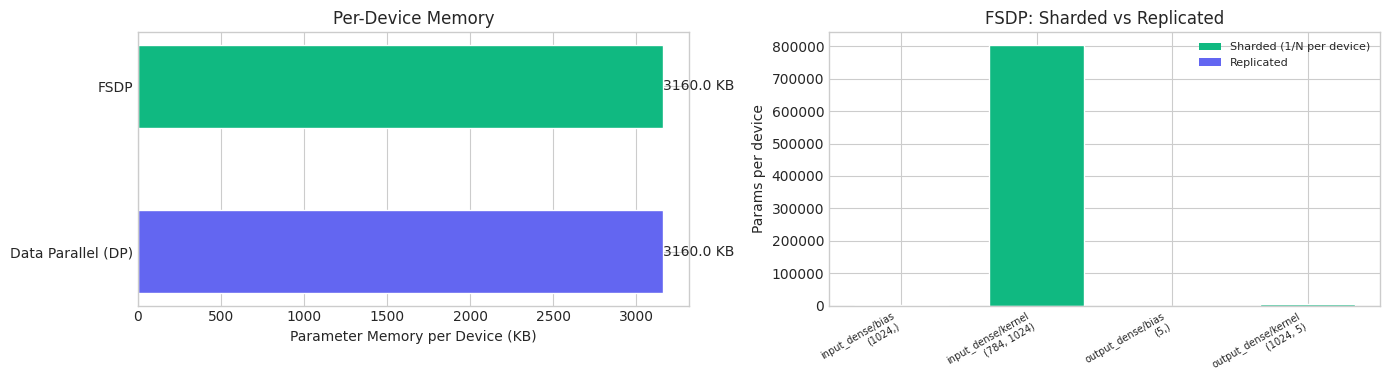

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Panel 1: Per-device memory bar chart ---
strategies = ["Data Parallel (DP)", "FSDP"]
memories = [dp_memory / 1024, fsdp_memory / 1024]
bar_colors = ["#6366f1", "#10b981"]

bars = axes[0].barh(strategies, memories, color=bar_colors, edgecolor="white", height=0.5)
for bar, m in zip(bars, memories):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                f"{m:.1f} KB", va="center", fontsize=10)
axes[0].set_xlabel("Parameter Memory per Device (KB)")
axes[0].set_title("Per-Device Memory")

# --- Panel 2: Sharded vs replicated parameters ---
fsdp_params = jax.device_get(state_fsdp.params)
fsdp_leaves = list(jax.tree_util.tree_leaves_with_path(
    fsdp_params, is_leaf=lambda x: isinstance(x, nn.Partitioned)
))

labels = []
sizes = []
is_sharded = []
for path, leaf in fsdp_leaves:
    name = "/".join(str(k.key) for k in path)
    if isinstance(leaf, nn.Partitioned):
        labels.append(f"{name}\n{leaf.value.shape}")
        sizes.append(np.prod(leaf.value.shape))
        is_sharded.append(True)
    else:
        labels.append(f"{name}\n{leaf.shape}")
        sizes.append(np.prod(leaf.shape))
        is_sharded.append(False)

x_pos = np.arange(len(labels))
colors_bar = ["#10b981" if s else "#6366f1" for s in is_sharded]
axes[1].bar(x_pos, sizes, color=colors_bar, edgecolor="white", width=0.7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels, fontsize=7, rotation=30, ha="right")
axes[1].set_ylabel("Params per device")
axes[1].set_title("FSDP: Sharded vs Replicated")

from matplotlib.patches import Patch
axes[1].legend(
    handles=[
        Patch(facecolor="#10b981", label="Sharded (1/N per device)"),
        Patch(facecolor="#6366f1", label="Replicated"),
    ],
    fontsize=8, loc="upper right",
)

plt.tight_layout()
plt.show()

---

## 14 — Communication Trade-offs

FSDP trades **more communication** for **less memory**:

| Operation | DP | FSDP |
|-----------|----|----- |
| **Forward** | None | `all_gather` per layer ($O(P)$ data) |
| **Backward** | `all_reduce` on gradients ($O(P)$) | `psum_scatter` per layer ($O(P)$) |
| **Total communication** | $O(P)$ | $O(2P)$ — 2x more |
| **Memory per device** | $O(P)$ | $O(P/N)$ — $N$x less |

For a 7B model on 8 GPUs: DP needs 28 GB/device, FSDP needs ~3.5 GB/device.

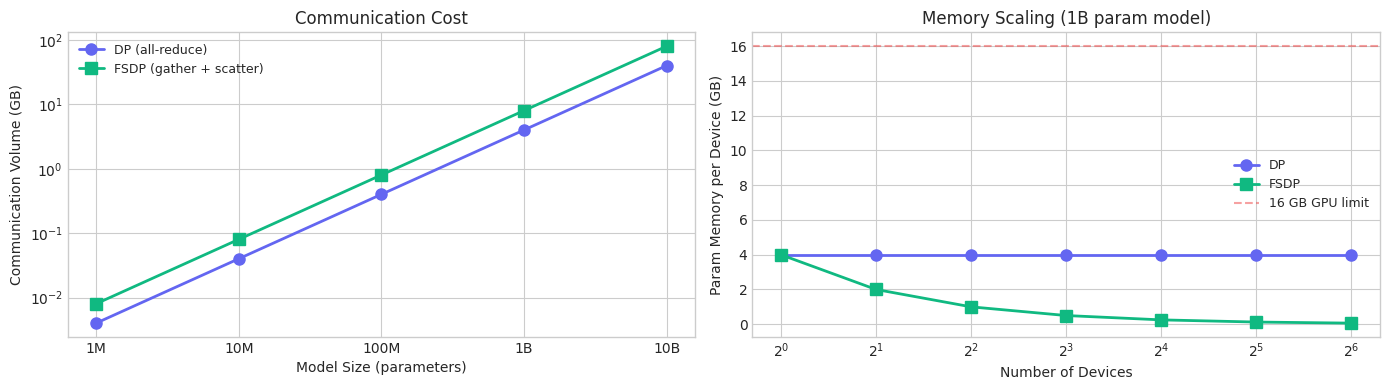

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Communication volume vs model size ---
model_sizes = np.array([1e6, 10e6, 100e6, 1e9, 10e9])
labels_sizes = ["1M", "10M", "100M", "1B", "10B"]

dp_comm = model_sizes * 4 / 1e9     # all-reduce: ~1 pass
fsdp_comm = model_sizes * 4 * 2 / 1e9  # 2 passes: gather + scatter

axes[0].plot(range(len(model_sizes)), dp_comm, 'o-', color="#6366f1",
             label="DP (all-reduce)", linewidth=2, markersize=8)
axes[0].plot(range(len(model_sizes)), fsdp_comm, 's-', color="#10b981",
             label="FSDP (gather + scatter)", linewidth=2, markersize=8)
axes[0].set_xticks(range(len(model_sizes)))
axes[0].set_xticklabels(labels_sizes)
axes[0].set_xlabel("Model Size (parameters)")
axes[0].set_ylabel("Communication Volume (GB)")
axes[0].set_title("Communication Cost")
axes[0].set_yscale("log")
axes[0].legend(fontsize=9)

# --- Memory per device vs number of devices ---
n_devices_range = np.array([1, 2, 4, 8, 16, 32, 64])
model_size_gb = 1e9 * 4 / 1e9  # 1B params in float32 → 4 GB

dp_mem = np.full_like(n_devices_range, model_size_gb, dtype=float)
fsdp_mem = model_size_gb / n_devices_range

axes[1].plot(n_devices_range, dp_mem, 'o-', color="#6366f1",
             label="DP", linewidth=2, markersize=8)
axes[1].plot(n_devices_range, fsdp_mem, 's-', color="#10b981",
             label="FSDP", linewidth=2, markersize=8)
axes[1].axhline(y=16, color="#ef4444", linestyle="--", alpha=0.5, label="16 GB GPU limit")
axes[1].set_xlabel("Number of Devices")
axes[1].set_ylabel("Param Memory per Device (GB)")
axes[1].set_title("Memory Scaling (1B param model)")
axes[1].set_xscale("log", base=2)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---

## Summary

FSDP builds on four JAX primitives combined in a specific pattern:

| Step | Primitive | What it does |
|------|----------|-------------|
| **1. Shard** | `lax.dynamic_slice_in_dim` | Split parameter along largest axis, each device keeps 1/N |
| **2. Gather** (forward) | `lax.all_gather` | Reconstruct full parameter for layer computation |
| **3. Scatter** (backward) | `lax.psum_scatter / N` | Distribute averaged gradients back to shards |
| **4. Sync** | `lax.pmean` | Average gradients for replicated (small) params only |

The `shard_module_params` wrapper via `nn.map_variables` makes this **transparent** — model code stays identical to standard DP.

**When to use FSDP**: when model parameters don't fit on a single device. The 2x communication overhead is negligible compared to the $N$x memory savings.